In [2]:
!pip install kaggle

In [3]:
from google.colab import files
files.upload()   # upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"divyajaisansaria","key":"1a64dcd79854e880eb039437106abd0d"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 454MB/s]


In [6]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [7]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Shape of dataset (rows, columns)
print("Shape:", df.shape)

# Column data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Summary statistics (only for numeric columns)
print("\nSummary Statistics:")
print(df.describe())

Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [9]:
# Convert TotalCharges to numeric, forcing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values again (some TotalCharges may become NaN now)
print(df.isnull().sum())

# Drop rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

# Confirm type
print(df["TotalCharges"].dtype)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
float64


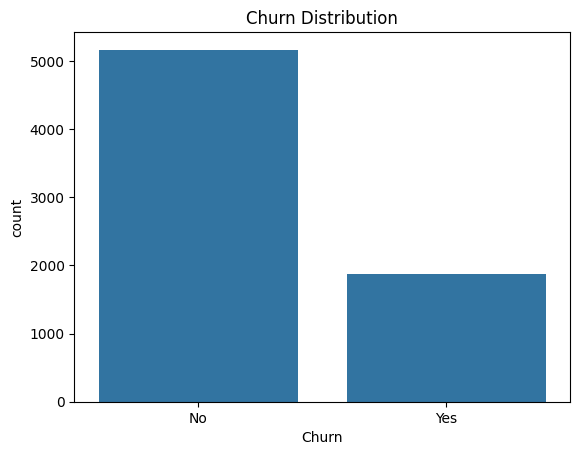

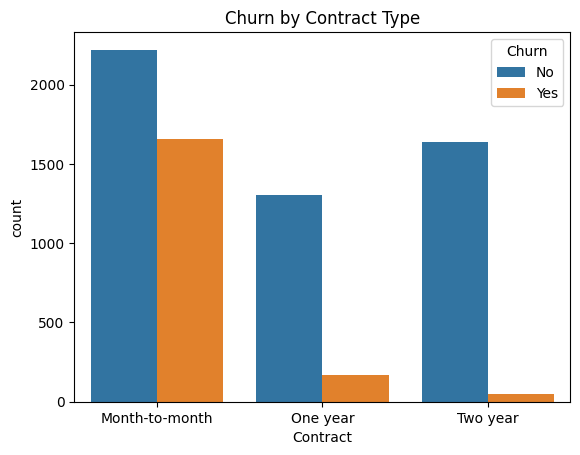

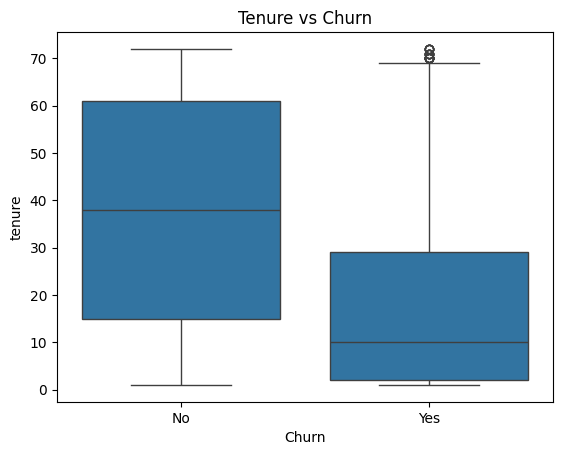

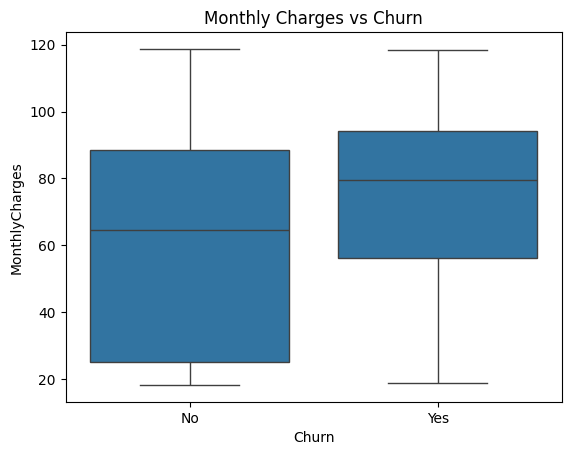

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Churn distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# 2. Churn by Contract type
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

# 3. Churn vs Tenure
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

# 4. Churn vs MonthlyCharges
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [11]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df["Contract"], df["Churn"])

# Chi-square test
chi2, p, dof, ex = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0 → Contract type affects churn")
else:
    print("Fail to reject H0 → Contract type does NOT affect churn")

Chi-square statistic: 1179.5458287339445
p-value: 7.326182186265472e-257
Reject H0 → Contract type affects churn


In [12]:
from scipy.stats import ttest_ind

# Tenure
tenure_churn = df[df["Churn"]=="Yes"]["tenure"]
tenure_no_churn = df[df["Churn"]=="No"]["tenure"]
t_stat, p_val = ttest_ind(tenure_churn, tenure_no_churn)
print("Tenure t-test p-value:", p_val)

# MonthlyCharges
mc_churn = df[df["Churn"]=="Yes"]["MonthlyCharges"]
mc_no_churn = df[df["Churn"]=="No"]["MonthlyCharges"]
t_stat, p_val = ttest_ind(mc_churn, mc_no_churn)
print("MonthlyCharges t-test p-value:", p_val)

Tenure t-test p-value: 9.437650217574845e-207
MonthlyCharges t-test p-value: 6.760843117980302e-60


In [13]:
df = df.drop("customerID", axis=1)

In [14]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [15]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [17]:
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [18]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.280248,-1.161694,-0.994194,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,0.064303,-0.260878,-0.173740,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,-1.239504,-0.363923,-0.959649,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.512486,-0.747850,-0.195248,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,-1.239504,0.196178,-0.940457,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train/Test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

We will try 4 models:
Logistic Regression
Decision Tree
Random Forest
K-Nearest Neighbors (KNN)

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8045486851457001
ROC-AUC: 0.7312860108401363
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Decision Tree
Accuracy: 0.7192608386638237
ROC-AUC: 0.6390879065698266
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.47      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407


Random Forest
Accuracy: 0.7896233120113717
ROC-AUC: 0.703211144529976
Classification Report:
               precision    recall  f1-score   support

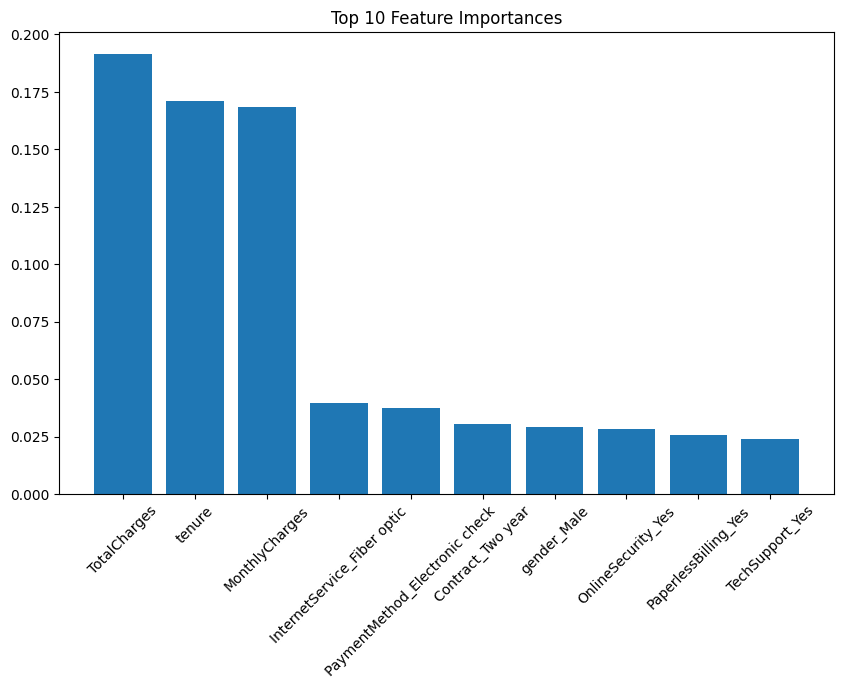

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Train Random Forest again for feature importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

# Plot top 10 features
plt.figure(figsize=(10,6))
plt.title("Top 10 Feature Importances")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), [features[i] for i in indices][:10], rotation=45)
plt.show()